In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, zero_one_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Dataset/bank-full.csv',sep=';')

df_numerica = df[['age','balance','duration','y']]

In [7]:
mapeamento = {'yes':1,'no':0}
df_numerica = df_numerica.replace(mapeamento)

Y = df_numerica['y']
X = df_numerica.drop(columns=['y'])

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=0)

rus = RandomUnderSampler(random_state=0)
X_train_balanceado, y_train_balanceado = rus.fit_resample(X_train, y_train)

scaler = StandardScaler()

X_train_balanceado = scaler.fit_transform(X_train_balanceado)
X_test = scaler.transform(X_test)

C:\Users\User\AppData\Local\Temp\ipykernel_10276\1637336092.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numerica = df_numerica.replace(mapeamento)


In [8]:
acs = []
erro_teste = []
erro_treino = []
K = np.arange(1,151,2)

for k in K:
    modelo = KNeighborsClassifier(n_neighbors=k)

    modelo.fit(X_train_balanceado,y_train_balanceado)

    Y_predict = modelo.predict(X_test)

    accuracy = accuracy_score(y_test,Y_predict)
    acs.append(accuracy)
    print(f'A acurácia do modelo KNN com {k} vizinhos foi de {accuracy*100:.2f}%')

    erro_teste.append(zero_one_loss(y_test,Y_predict))

    Y_predict_treino = modelo.predict(X_train_balanceado)
    erro_treino.append(zero_one_loss(y_train_balanceado,Y_predict_treino))

matriz_c = confusion_matrix(y_test,Y_predict)
#print(matriz_c)

plt.figure(figsize=(6, 4))
# annot=True mostra os números, fmt='d' garante que sejam inteiros
sns.heatmap(matriz_c, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto: 0', 'Previsto: 1'], 
            yticklabels=['Real: 0', 'Real: 1'])

plt.title('Matriz de Confusão')
plt.ylabel('Valor Verdadeiro (Gabarito)')
plt.xlabel('Valor Previsto pelo Modelo')
plt.tight_layout()
plt.show()

A acurácia do modelo KNN com 1 vizinhos foi de 67.46%
A acurácia do modelo KNN com 3 vizinhos foi de 70.66%
A acurácia do modelo KNN com 5 vizinhos foi de 71.76%
A acurácia do modelo KNN com 7 vizinhos foi de 72.52%
A acurácia do modelo KNN com 9 vizinhos foi de 72.74%
A acurácia do modelo KNN com 11 vizinhos foi de 72.98%
A acurácia do modelo KNN com 13 vizinhos foi de 73.06%
A acurácia do modelo KNN com 15 vizinhos foi de 73.09%
A acurácia do modelo KNN com 17 vizinhos foi de 73.07%
A acurácia do modelo KNN com 19 vizinhos foi de 73.18%
A acurácia do modelo KNN com 21 vizinhos foi de 73.33%
A acurácia do modelo KNN com 23 vizinhos foi de 73.49%
A acurácia do modelo KNN com 25 vizinhos foi de 73.44%
A acurácia do modelo KNN com 27 vizinhos foi de 73.50%


KeyboardInterrupt: 

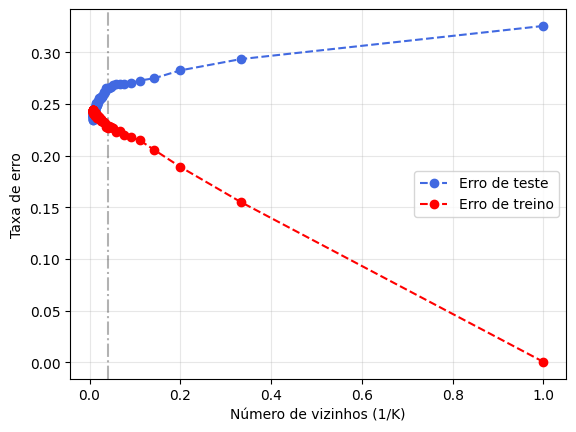

In [ ]:

plt.figure()
plt.grid(alpha=0.3)
plt.axvline(x=1/25,ls='-.',color='black',alpha=0.3)

#plt.plot([1,0.5],erro_teste[0:2],color='royalblue',marker='o',ls='--')
#plt.plot([1,0.5],erro_treino[0:2],color='red',marker='o',ls='--')

plt.plot(1/K[:],erro_teste[:],color='royalblue',marker='o',ls='--',label='Erro de teste')
plt.plot(1/K[:],erro_treino[:],color='red',marker='o',ls='--',label='Erro de treino')
#plt.xticks(np.arange(1,21,2))
plt.xlabel('Número de vizinhos (1/K)')
plt.ylabel('Taxa de erro')
#plt.ylim(erro_treino[2],erro_teste[2])
#plt.xlim(1/K[-1],1/25)

plt.legend()
plt.show()

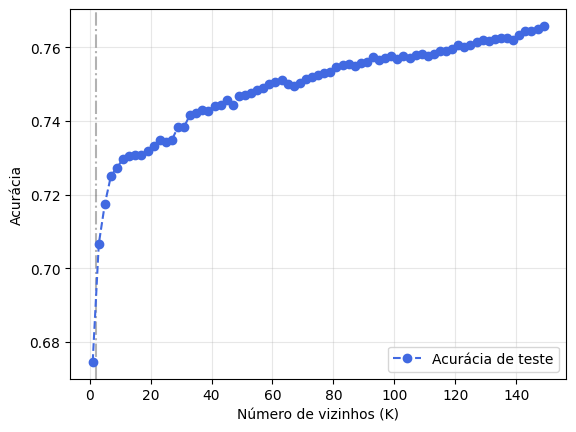

In [ ]:
plt.figure()
plt.grid(alpha=0.3)
plt.axvline(x=2,ls='-.',color='black',alpha=0.3)

plt.plot(K,acs[:],color='royalblue',marker='o',ls='--',label='Acurácia de teste')

plt.xlabel('Número de vizinhos (K)')
plt.ylabel('Acurácia')
#plt.ylim(erro_treino[2],erro_teste[2])
#plt.xlim(1/K[-1],1/K[2])

plt.legend()
plt.show()